In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime


In [3]:
df = pd.read_csv("../../external_data/jasper_ridge/Jasper Ridge N5/Stanford_Raw-data-2026-01-24_25_N5_sensors_cultural_burn.csv", parse_dates=[0])



In [4]:
df.columns

Index(['time', 'stationID', 'T', 'RH', 'PM1P0', 'PM2P5', 'Smoke_score'], dtype='object')

In [28]:
sensorNames = df["stationID"].unique()

In [29]:
df02 = df[df["stationID"]=='aa-87-15-02']

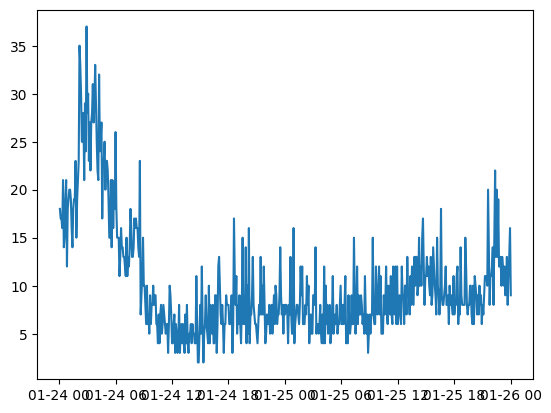

0      2026-01-24 00:05:00
3      2026-01-24 00:10:00
6      2026-01-24 00:15:00
9      2026-01-24 00:20:00
12     2026-01-24 00:25:00
               ...        
1712   2026-01-25 23:40:00
1715   2026-01-25 23:45:00
1718   2026-01-25 23:50:00
1721   2026-01-25 23:55:00
1724   2026-01-26 00:00:00
Name: time, Length: 575, dtype: datetime64[ns]

In [30]:
plt.plot(df02["time"], df02["PM2P5"])
plt.show()
df02["time"]

In [31]:
def plotN5data(yAxis, opacity, log, ylim, ylabel):
    """
    Plot N5 data with respect to inputs

    Inputs:
        yAxis: str - What data to plot
        opacity: float - Opacity of the plotted data
        log: Boolean - Whether or not to plot in log scale
        ylim: int - Limit of the y-axis
        ylabel: str - Label of y-axis
    Outputs:
        None: Plots a N5 Graph
    """
    _, ax = plt.subplots(1, 1, figsize=(10, 4)) #
    for sensorName in sensorNames:

        curr_data_df = df[df["stationID"]==sensorName]
        ax.plot(curr_data_df["time"], curr_data_df[yAxis], alpha=opacity, label = sensorName)
        
        if log:
            ax.set_yscale("log")

        earliest_day = curr_data_df['time'].iloc[0].date()
        latest_day = curr_data_df['time'].iloc[-1].date()

        sunrise = datetime.datetime.strptime("06:00:00", "%H:%M:%S").time() 
        sunset = datetime.datetime.strptime("18:00:00", "%H:%M:%S").time()

        # Print each day between the earliest and latest day
        num_days = (latest_day - earliest_day).days + 1
        for i in range(num_days):
            curr_day = earliest_day + datetime.timedelta(days=i)

            curr_sunrise_datetime = datetime.datetime.combine(curr_day, sunrise)
            curr_sunset_datetime = datetime.datetime.combine(curr_day, sunset)
            ax.axvspan(curr_sunset_datetime - datetime.timedelta(days=1), 
                    curr_sunrise_datetime, 
                    color='#bfbfbf', alpha=0.25, zorder=0)
        ax.set_xlabel("Time")
        ax.set_ylabel(ylabel)
        # ax.set_title(curr_data_df.iloc[0]["stationID"])
    plt.grid(True, c="#a8a8a8")
    plt.ylim(top = ylim)
    plt.legend(bbox_to_anchor=[1.01, 1], loc = "upper left", markerscale = 3)
    if log:
        plt.savefig(f"N5_Log_{ylabel}.png", dpi = 150, bbox_inches="tight")
    else:
        plt.savefig(f"N5_{ylabel}.png", dpi = 150, bbox_inches="tight")

PM 2.5

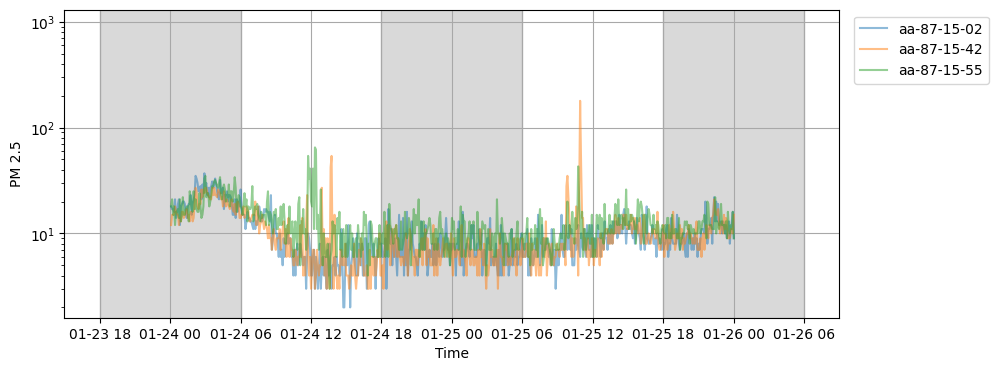

In [32]:
plotN5data("PM2P5", 0.5, True, 1300, "PM 2.5")

PM 1.0

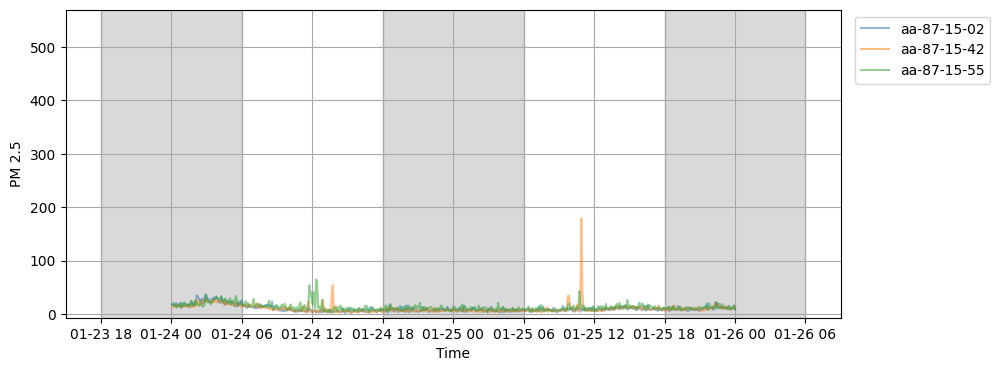

In [33]:
plotN5data("PM2P5", 0.5, False, 570, "PM 2.5")

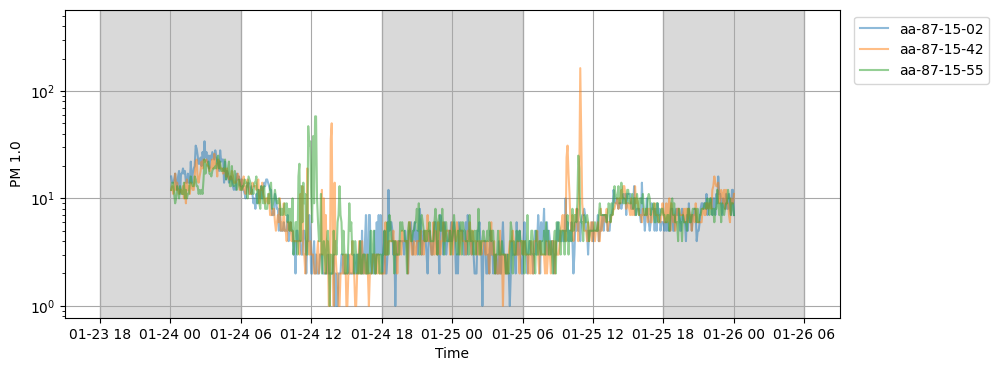

In [34]:
plotN5data("PM1P0", 0.5, True, 570, "PM 1.0")

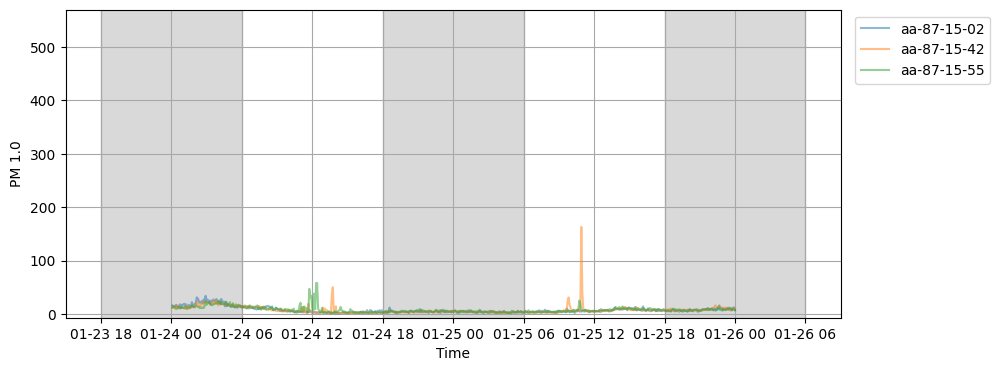

In [35]:
plotN5data("PM1P0", 0.5, False, 570, "PM 1.0")

Temperature

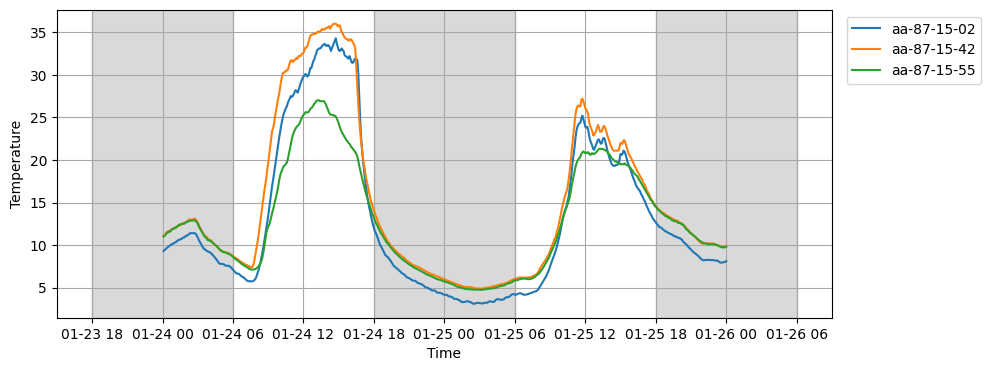

In [36]:
plotN5data("T", 1, False, None, "Temperature")

Relative Humidity

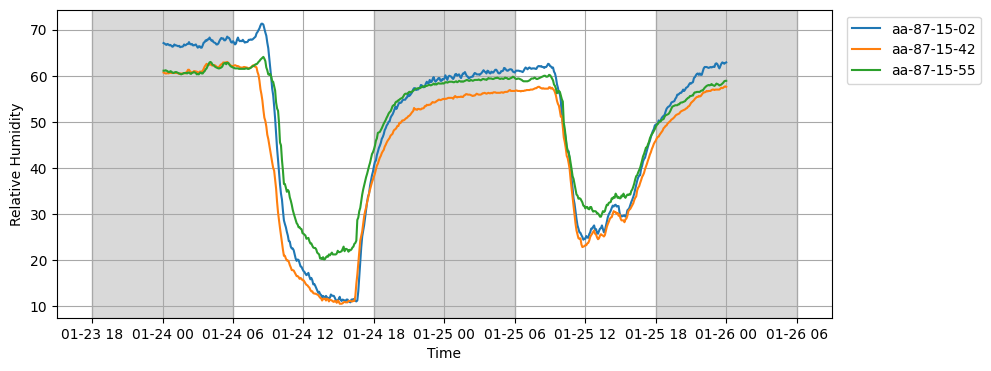

In [37]:
plotN5data("RH", 1, False, None, "Relative Humidity")